# Logistic Regression Implementation


---


### 01. Library Installation


In [65]:
%pip install -qq matplotlib numpy pandas scikit-learn seaborn


Note: you may need to restart the kernel to use updated packages.


### 02. Library Imports


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from pandas.api.types import CategoricalDtype

### 03. Data Loading and Preprocessing


Looking at the dataset that will be processed, this is the **Car Evaluation Dataset** which contains data about car acceptability based on various attributes. The dataset was derived from a hierarchical decision model originally developed for demonstrating decision-making expert systems and is used for multi-class classification.

**Dataset characteristics:**
- **Total samples**: 1,728 observations
- **Features**: 6 categorical variables representing car characteristics
- **Target**: Multi-class classification (Car acceptability)
    - Class 0: unacc (unacceptable) - 1,210 samples (70.0%)
    - Class 1: acc (acceptable) - 384 samples (22.2%)
    - Class 2: good - 69 samples (4.0%)
    - Class 3: v-good (very good) - 65 samples (3.8%)

**Feature descriptions:**
- `buying`: Buying price (vhigh, high, med, low)
- `maint`: Maintenance price (vhigh, high, med, low)
- `doors`: Number of doors (2, 3, 4, 5more)
- `persons`: Capacity in terms of persons to carry (2, 4, more)
- `lug_boot`: Size of luggage boot (small, med, big)
- `safety`: Estimated safety of the car (low, med, high)

**Dataset context:**
This dataset was created from a hierarchical decision model that evaluates cars according to a structured concept hierarchy:
- **PRICE** (overall price): buying + maintenance costs
- **TECH** (technical characteristics): includes comfort and safety
- **COMFORT**: doors + persons + luggage boot capacity

**Key characteristics:**
- **Complete attribute space coverage**: The dataset contains all possible combinations of attribute values
- **No missing values**: All instances have complete information
- **Ordinal features**: All attributes have natural ordering (low → high, small → big, etc.)
- **Multi-class imbalance**: Strong class imbalance with 70% unacceptable cars

**Research applications:**
This dataset is particularly valuable for:
- **Multi-class classification**: Testing algorithms on imbalanced multi-class problems
- **Ordinal feature handling**: Understanding how algorithms process ordered categorical data
- **Decision tree analysis**: The hierarchical structure makes it ideal for tree-based methods
- **Feature importance studies**: Clear interpretable features for understanding model decisions
- **Constructive induction**: Testing structure discovery methods due to known concept hierarchy

**Real-world relevance:**
The dataset models practical car purchasing decisions where buyers consider multiple factors simultaneously. The hierarchical structure reflects how humans actually make complex decisions by breaking them into sub-problems (price vs. technical features vs. comfort).


In [67]:
# Importing and checking the dataframe

dataframe = pd.read_csv('../../datasets/car_evaluation/car.data', sep = ',', header = None)
dataframe.head()


,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [68]:
# Renaming columns accordingly to the dataset documentation

columns_name = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
dataframe.columns = columns_name
dataframe.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


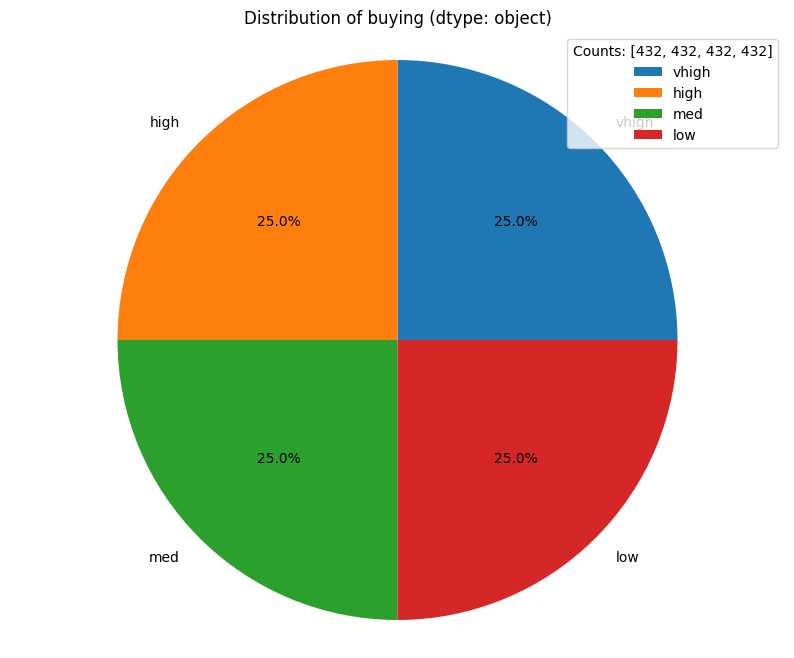

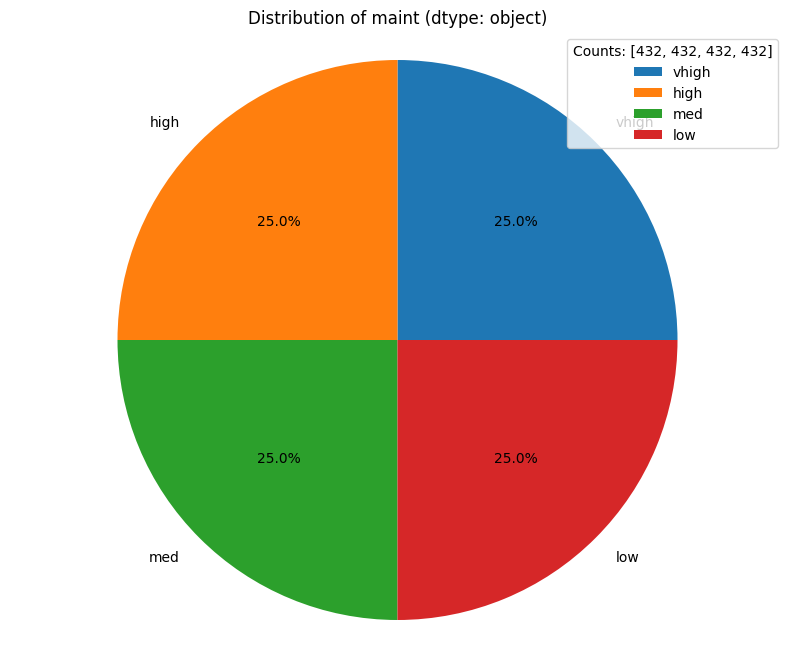

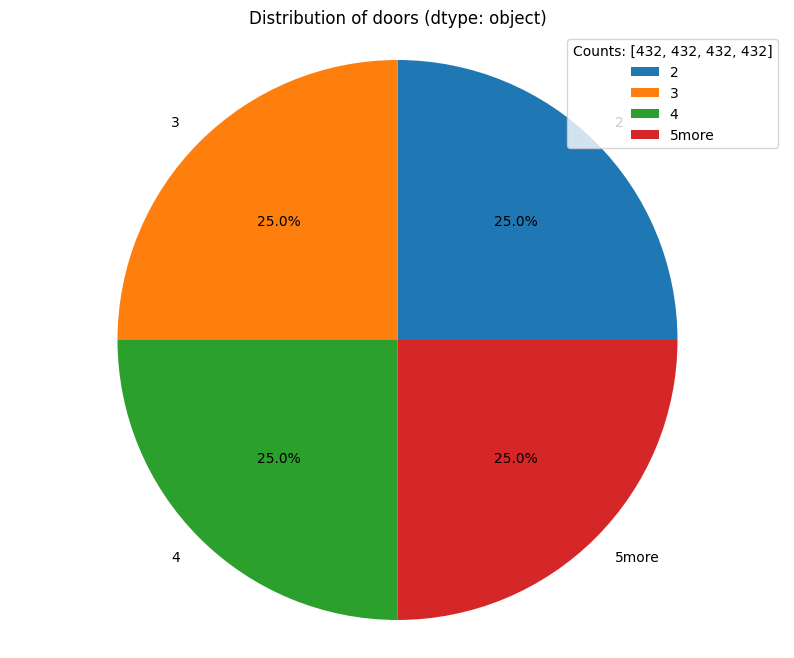

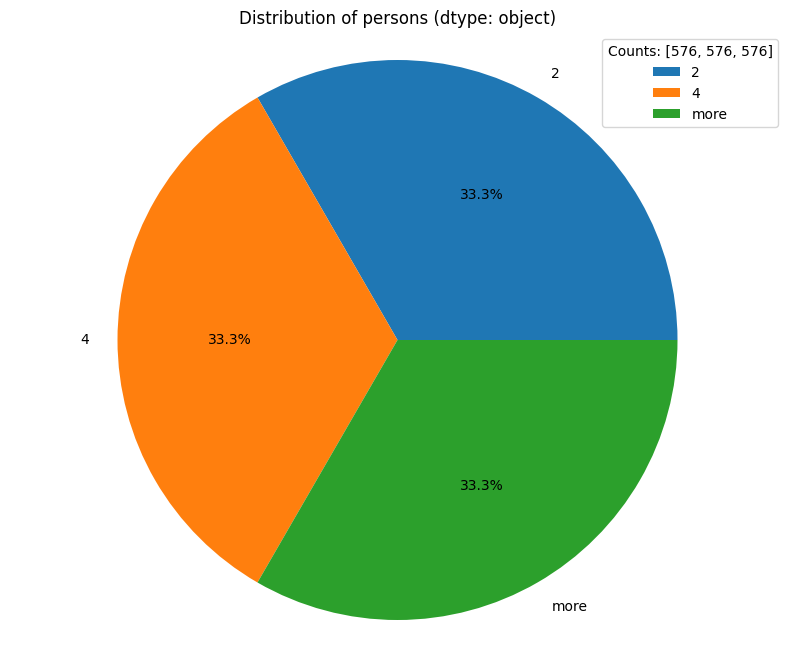

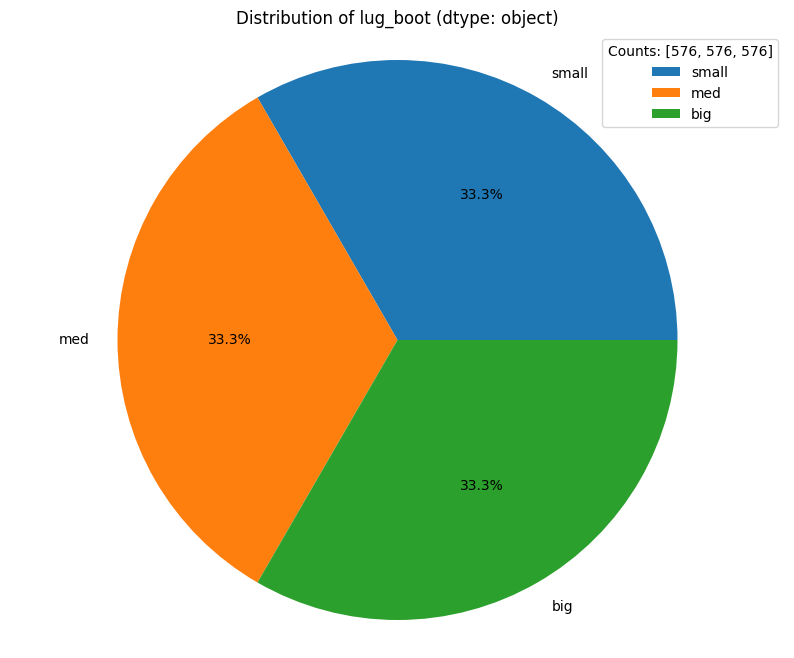

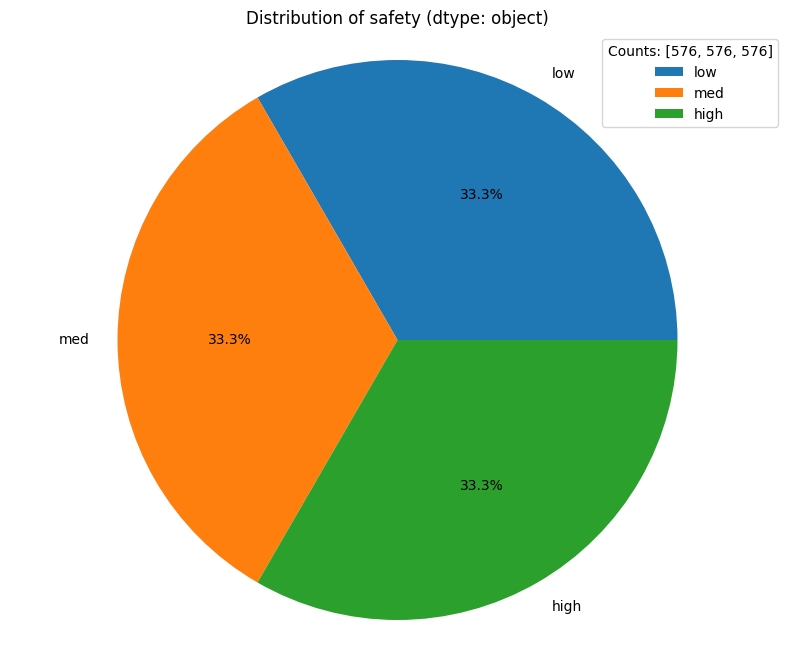

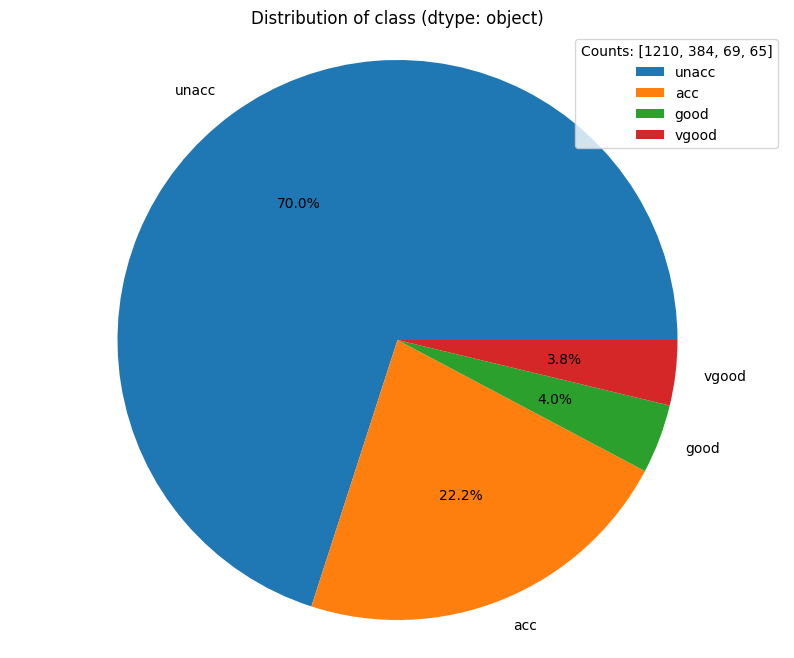

In [69]:
# Checking the values and types of each column

for column in dataframe.columns:
    labels = dataframe[column].value_counts().index.tolist()
    counts = dataframe[column].value_counts().values.tolist()
    dtype = dataframe[column].dtype

    figure = plt.figure(figsize = (10, 8))
    plt.pie(counts, labels = labels, autopct = '%1.1f%%')
    plt.axis('equal')
    plt.legend(title = f"Counts: {counts}")
    plt.title(f"Distribution of {column} (dtype: {dtype})")
    plt.show()
    

In [70]:
# Changing the data types of categorical columns

buying_type = CategoricalDtype(categories = ['vhigh', 'high', 'med', 'low'], ordered = True)
maint_type = CategoricalDtype(categories = ['vhigh', 'high', 'med', 'low'], ordered = True)
doors_type = CategoricalDtype(categories = ['2', '3', '4', '5more'], ordered = True)
persons_type = CategoricalDtype(categories = ['2', '4', 'more'], ordered = True)
lug_boot_type = CategoricalDtype(categories = ['small', 'med', 'big'], ordered = True)
safety_type = CategoricalDtype(categories = ['low', 'med', 'high'], ordered = True)

dataframe['buying'] = dataframe['buying'].astype(buying_type)
dataframe['maint'] = dataframe['maint'].astype(maint_type)
dataframe['doors'] = dataframe['doors'].astype(doors_type)
dataframe['persons'] = dataframe['persons'].astype(persons_type)
dataframe['lug_boot'] = dataframe['lug_boot'].astype(lug_boot_type)
dataframe['safety'] = dataframe['safety'].astype(safety_type)


In [71]:
dataframe.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [72]:
# Converting categorical columns to numerical values

dataframe['buying'] = dataframe['buying'].cat.codes
dataframe['maint'] = dataframe['maint'].cat.codes
dataframe['doors'] = dataframe['doors'].cat.codes
dataframe['persons'] = dataframe['persons'].cat.codes
dataframe['lug_boot'] = dataframe['lug_boot'].cat.codes
dataframe['safety'] = dataframe['safety'].cat.codes
dataframe['class'] = dataframe['class'].astype('category').cat.codes

dataframe.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,0,0,0,0,0,0,2
1,0,0,0,0,0,1,2
2,0,0,0,0,0,2,2
3,0,0,0,0,1,0,2
4,0,0,0,0,1,1,2


### 04. Data Visualization


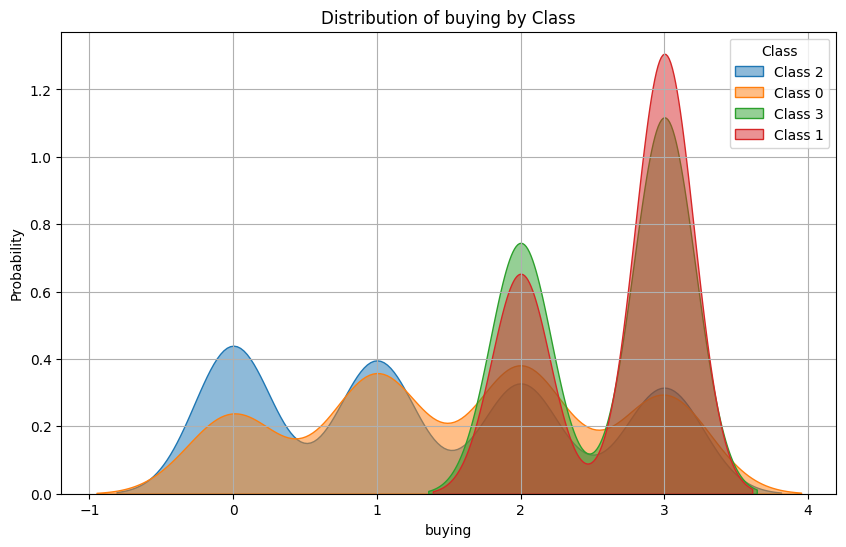

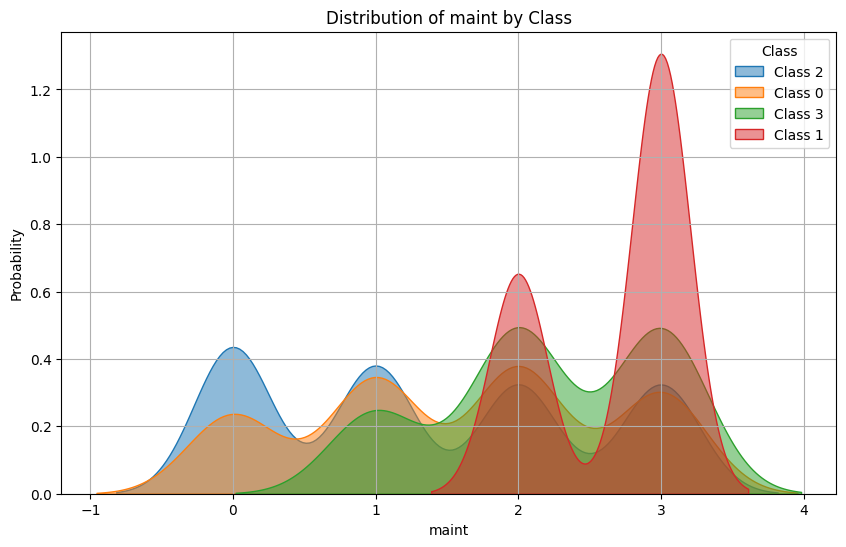

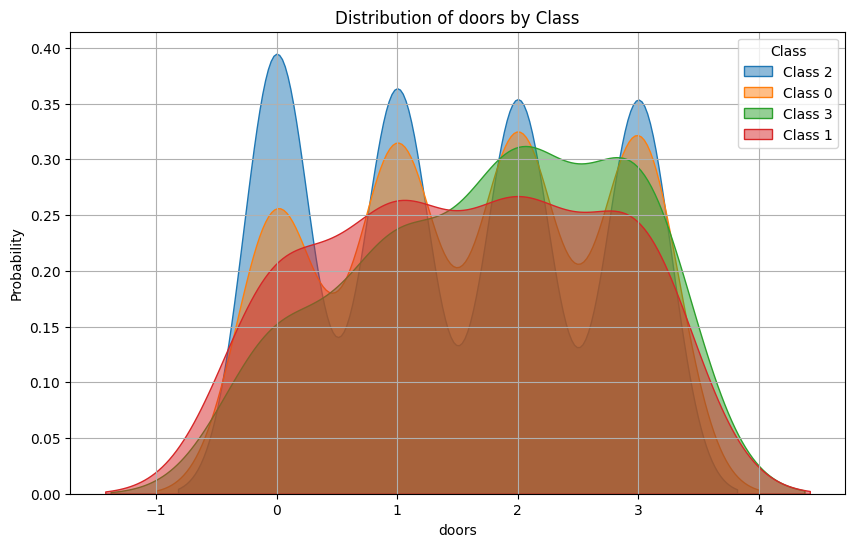

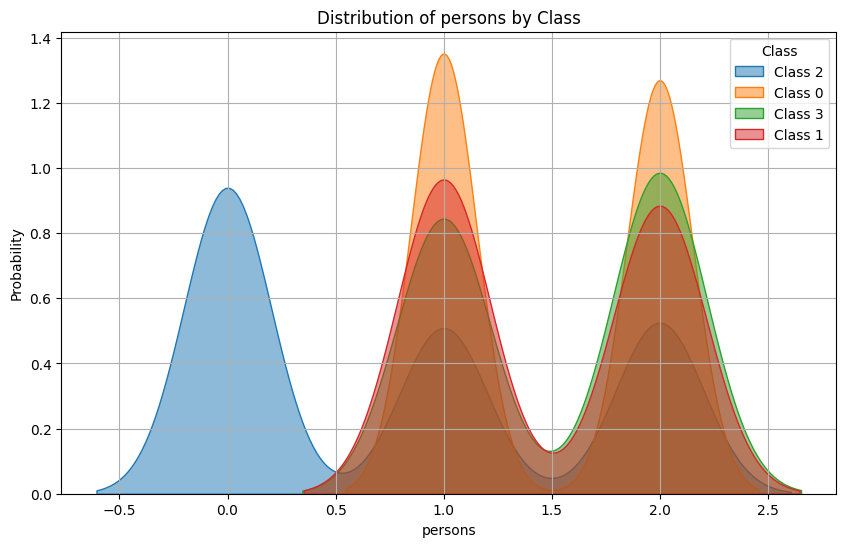

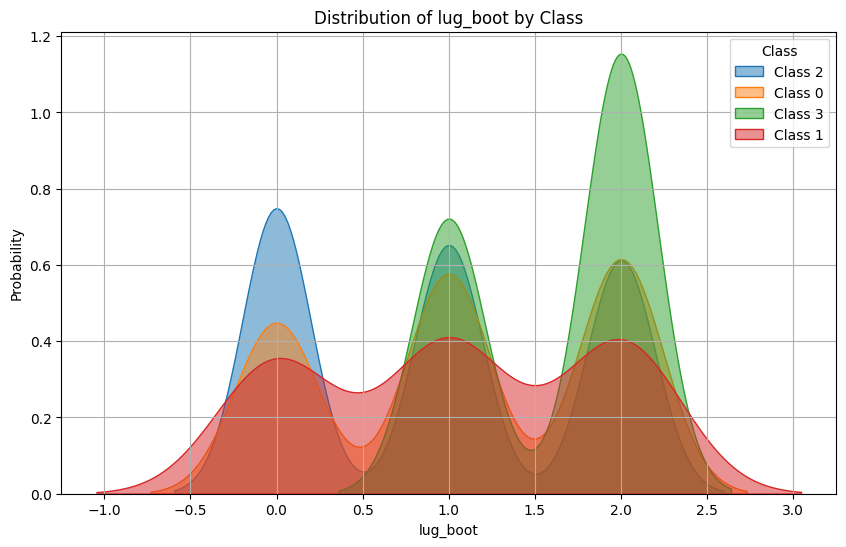

/tmp/ipykernel_58983/494641111.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[label], fill = True, alpha = 0.5, label = f'Class {class_value}')


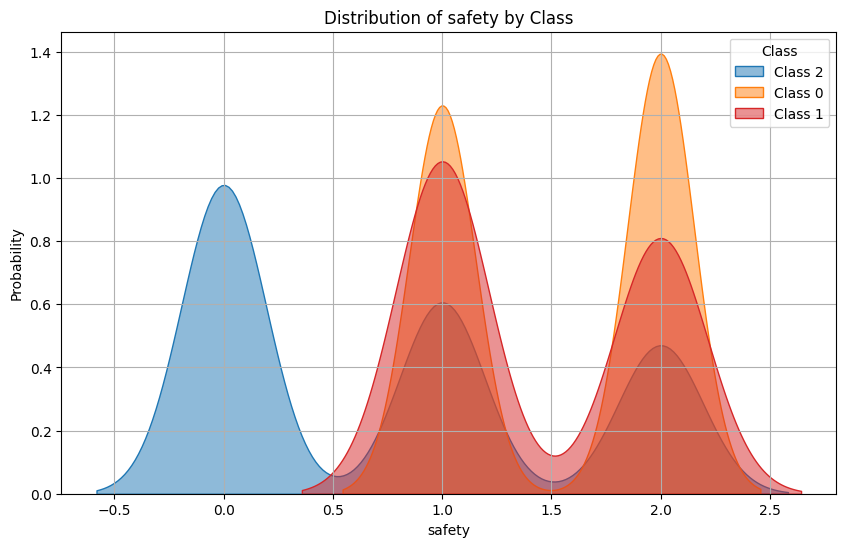

In [73]:
for label in dataframe:
    if label == 'class' or dataframe[label].dtype == 'object':
        continue

    plt.figure(figsize = (10, 6))

    for class_value in dataframe['class'].unique():
        subset = dataframe[dataframe['class'] == class_value]
        sns.kdeplot(subset[label], fill = True, alpha = 0.5, label = f'Class {class_value}')

    plt.title(f'Distribution of {label} by Class')
    plt.xlabel(label)
    plt.ylabel('Probability')
    plt.legend(title = 'Class')
    plt.grid()

    plt.show()


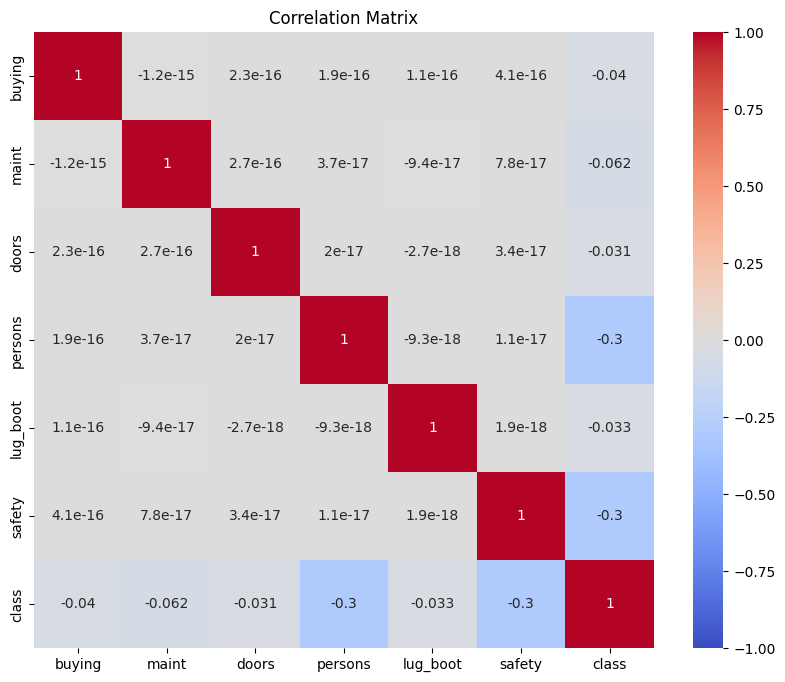

In [74]:
# Checking the correlation matrix

plt.figure(figsize = (10, 8))
sns.heatmap(dataframe.corr(), annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Correlation Matrix')
plt.show()


### 05. Dataset Splitting and Scaling


In [75]:
# Shuffling the dataframe

dataframe = dataframe.sample(frac = 1, random_state = 42).reset_index(drop = True)


In [76]:
dataframe.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   int8 
 1   maint     1728 non-null   int8 
 2   doors     1728 non-null   int8 
 3   persons   1728 non-null   int8 
 4   lug_boot  1728 non-null   int8 
 5   safety    1728 non-null   int8 
 6   class     1728 non-null   int8 
dtypes: int8(7)
memory usage: 11.9 KB


In [77]:
dataframe.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,1,1,2,0,1,2,2
1,2,3,0,1,1,1,0
2,1,1,3,0,2,1,2
3,3,1,3,1,1,1,0
4,2,3,2,2,1,0,2


In [78]:
# Defining the train, validation and test datasets sizes

train_size = 0.7
validation_size = 0.15
test_size = 0.15


In [79]:
# Defining the train, validation and test datasets

train_dataset = dataframe[:int(train_size * len(dataframe))]
validation_dataset = dataframe[int(train_size * len(dataframe)):int((train_size + validation_size) * len(dataframe))]
test_dataset = dataframe[int((train_size + validation_size) * len(dataframe)):]

print('\nDatasets sizes:')
print(f'Train dataset size: {len(train_dataset)} samples')
print(f'Validation dataset size: {len(validation_dataset)} samples')
print(f'Test dataset size: {len(test_dataset)} samples')



Datasets sizes:
Train dataset size: 1209 samples
Validation dataset size: 259 samples
Test dataset size: 260 samples


In [80]:
X_train, y_train = train_dataset.drop('class', axis = 1), train_dataset['class']
X_validation, y_validation = validation_dataset.drop('class', axis = 1), validation_dataset['class']
X_test, y_test = test_dataset.drop('class', axis = 1), test_dataset['class']


### 06. Logistic Regression Implementation and Evaluation


In [81]:
# Logistic Regression implementation

logistic_regression_model = LogisticRegression(max_iter = 200)
logistic_regression_model.fit(X_train, y_train)

y_predictions_validation = logistic_regression_model.predict(X_validation)
y_predictions_test = logistic_regression_model.predict(X_test)


In [82]:
# Classification reports

print('Validation Set Classification Report:')
print(classification_report(y_validation, y_predictions_validation))

print('Test Set Classification Report:')
print(classification_report(y_test, y_predictions_test))


Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.52      0.58        60
           1       0.44      0.40      0.42        10
           2       0.86      0.93      0.90       180
           3       1.00      0.89      0.94         9

    accuracy                           0.81       259
   macro avg       0.74      0.68      0.71       259
weighted avg       0.80      0.81      0.81       259

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74        65
           1       0.71      0.36      0.48        14
           2       0.88      0.95      0.91       168
           3       0.73      0.62      0.67        13

    accuracy                           0.84       260
   macro avg       0.77      0.66      0.70       260
weighted avg       0.84      0.84      0.83       260



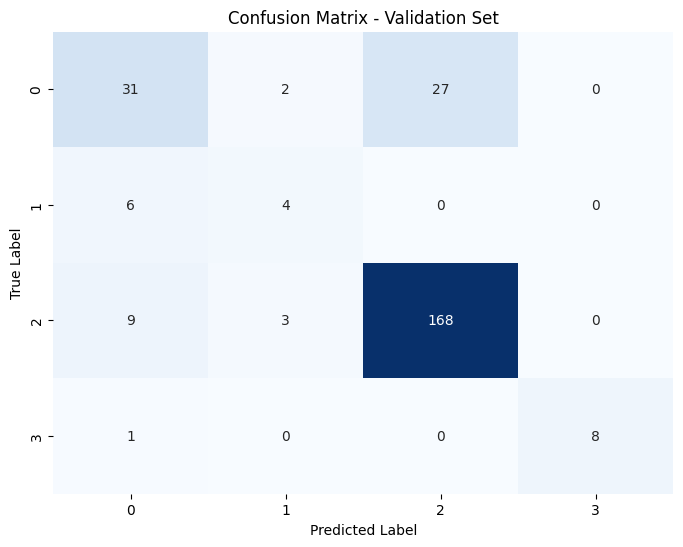

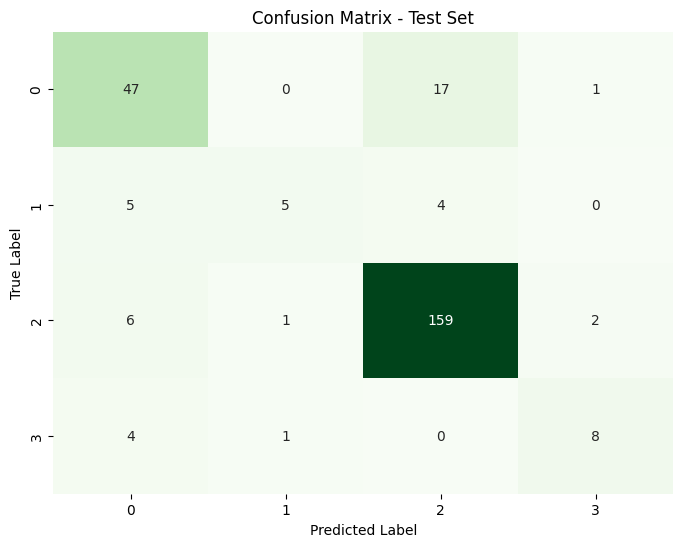

In [83]:
# Confusion matrix

confusion_matrix_validation = confusion_matrix(y_validation, y_predictions_validation)
confusion_matrix_test = confusion_matrix(y_test, y_predictions_test)

plt.figure(figsize = (8, 6))
sns.heatmap(confusion_matrix_validation, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize = (8, 6))
sns.heatmap(confusion_matrix_test, annot = True, fmt = 'd', cmap = 'Greens', cbar = False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
